(-1.0, 6.0)

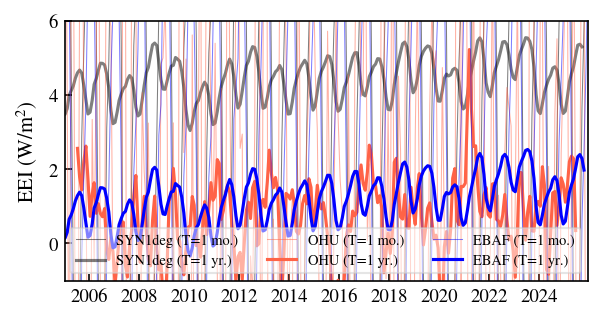

In [ ]:
# figure for FINESST
import sys, os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import RegularLatLonGrid
from SpaceBalls.utils import normal_smoother, normal_smoother_uneven, normal_smoother_uneven_2
from SpaceBalls.paths import MEDIA_DIR
import pandas as pd
from config.constants import earth_radius
RE = earth_radius(units='m')
S = 4 * np.pi * RE**2
base_dir = os.path.join(MEDIA_DIR, 'true_EEI', 'ceres_dataproducts')

ohc_fname = 'monthly-ocean-heat-2000m.csv'
ohc_dataset = pd.read_csv(os.path.join(base_dir, ohc_fname), sep=',', header=0) #np.loadtxt(os.path.join(base_dir, ohc_fname), skiprows=1, delimiter=',')
ohc_dataset
dates = pd.to_datetime(ohc_dataset['Day'])
dates = np.array(dates)
time_array = np.asarray(dates, dtype=np.float64)  # nanoseconds
time_array = (time_array - time_array[0]) /1e9
time_array_days = time_array / 3600 / 24
ohc_array = np.array(ohc_dataset['Monthly average ocean heat content for the 0-2000 meters layer']) *1e22 # Joules
ohu = np.gradient(ohc_array, time_array) /S / 0.9

ceres_grid = RegularLatLonGrid(alt_km=0, n_lat=180, n_lon=360)

ebaf_fname = 'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202604.nc'
syn1deg_fname_1 = 'CERES_SYN1deg-Month_Terra-Aqua-NOAA20_Ed4.2_Subset_200003-202603.nc'

ebaf_dataset = xr.open_dataset(os.path.join(base_dir, ebaf_fname))
time_ebaf = ebaf_dataset['time'].to_numpy()
time_ebaf_days = (time_ebaf - time_ebaf[0]) / (1e9 * 24 * 3600)
net_ebaf = ebaf_dataset['toa_net_all_mon'].to_numpy()
month_eei_ebaf = ceres_grid.compute_surf_integral(np.moveaxis(net_ebaf, 0, -1), average=True)
yr_eei_ebaf = normal_smoother_uneven_2(month_eei_ebaf, time_ebaf_days, 365.24, out_length_mode='same_with_nans')

ebaf_fname_global = 'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202604_globalmean.nc'
ebaf_dataset_global = xr.open_dataset(os.path.join(base_dir, ebaf_fname_global))
month_eei_ebaf_gloabl = ebaf_dataset_global['gtoa_net_all_mon'].to_numpy()
yr_eei_ebaf_global = normal_smoother_uneven_2(month_eei_ebaf_gloabl, time_ebaf_days, 365.24, out_length_mode='same_with_nans')

syn1deg_dataset_1 = xr.open_dataset(os.path.join(base_dir, syn1deg_fname_1))
time_syn1deg = syn1deg_dataset_1['time'].to_numpy()
time_syn1deg_days = (time_syn1deg - time_syn1deg[0]) / (1e9 * 24 * 3600)
net_syn1deg = syn1deg_dataset_1['toa_net_all_mon'].to_numpy()
month_eei_syn1deg = ceres_grid.compute_surf_integral(np.moveaxis(net_syn1deg, 0, -1), average=True)
yr_eei_syn1deg = normal_smoother(month_eei_syn1deg, np.arange(len(month_eei_syn1deg)), 12, out_length_mode='same_with_nans')

syn1deg_fname_1_global = 'CERES_SYN1deg-Month_Terra-Aqua-NOAA20_Ed4.2_Subset_200003-202603_globalmean.nc'
syn1deg_dataset_1_global = xr.open_dataset(os.path.join(base_dir, syn1deg_fname_1_global))
net_syn1deg_global = syn1deg_dataset_1_global['gtoa_net_all_mon'].to_numpy()
yr_eei_syn1deg_global = normal_smoother_uneven_2(net_syn1deg_global, time_syn1deg_days, 365.24, out_length_mode='same_with_nans')

fig, ax = plt.subplots(figsize=(4.5,2.25))
#fig, ax = plt.subplots(figsize=(10,2.5))
#ax.plot(time_syn1deg, month_eei_syn1deg, color='k', lw=0.5, alpha=0.5, label='SYN1deg (T=1 mo.)')
ax.plot(time_syn1deg, yr_eei_syn1deg_global,  color='k', alpha=0.5, label='SYN1deg (T=1 yr.)')

ohu_smooth = normal_smoother_uneven_2(ohu, time_array_days, 365.24, out_length_mode='same_with_nans')

#ax.plot(dates, ohu, color='tomato', lw=0.5, alpha=0.5, label='OHU (T=1 mo.)')
ax.plot(dates, ohu_smooth, color='tomato', label='OHU (T=1 yr.)')

#ax.plot(time_ebaf, month_eei_ebaf, color='b', lw=0.5, alpha=0.5, label='EBAF (T=1 mo.)')
#ax.plot(time_ebaf, yr_eei_ebaf, color='b', label='EBAF (T=1 yr.)')
ax.plot(time_ebaf, yr_eei_ebaf_global, color='b', label='EBAF (T=1 yr.)')


ax.set_ylabel('EEI (W/m$^2$)')
ax.set_xlim([dates[0], dates[-1]])
#ax.set_yscale('symlog', linthresh=2)
ax.legend(fontsize='x-small', ncols=3, loc='lower right', 
    frameon=True,      # Enable the legend box
    framealpha=0.5,    # Transparency (0 = fully transparent, 1 = opaque)
    facecolor='white', # Background color
    edgecolor=None   # Border color)
)



In [12]:
np.mean(month_eei_ebaf[18:30])

np.float64(0.2582045441588067)

Getting output variable: srp_recomp_radial
Getting output variable: erp_recomp_radial_131
Getting output variable: aero
Getting output variable: jd_vec


/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/utils.py:457: RuntimeWarning: divide by zero encountered in power
  actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)


Subsampling time hist: orig. shape: (94608000,); downsample_fact=30
Subsampling time hist: final shape: (3153599,)
Subsampling time hist: orig. shape: (94608000,); downsample_fact=30
Subsampling time hist: final shape: (3153599,)
Subsampling time hist: orig. shape: (94608000,); downsample_fact=30
Subsampling time hist: final shape: (3153599,)


/tmp/ipykernel_2298628/1043298875.py:89: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_psd.set_xlim([freqs_noise[0], freqs_noise[-1]])


/tmp/ipykernel_2298628/1043298875.py:87: RuntimeWarning: divide by zero encountered in divide
  ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))


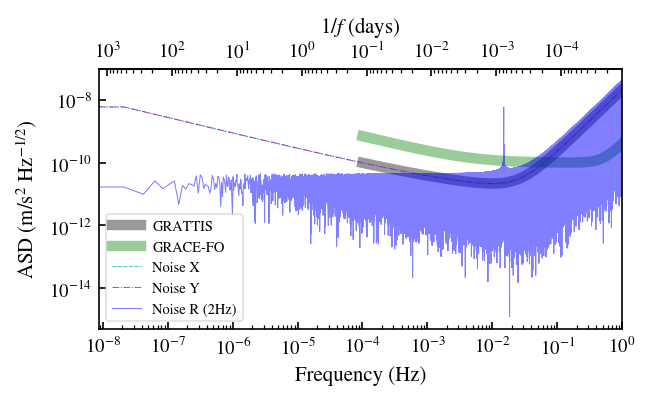

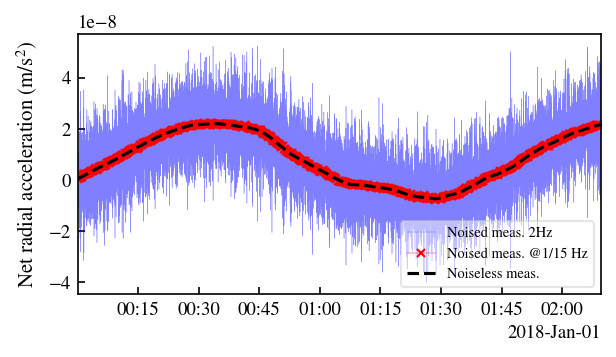

In [ ]:
# This block is based on the file notes_on_acc_errors.ipynb
# report figures have been generated with T=1.5yr and orbit G3
import numpy as np
import scipy.fft
import matplotlib.pyplot as plt
from SpaceBalls.utils import normal_smoother, downsample_array, fft_to_power, noise_asd_grattis, noise_asd_grace, smoother_ai
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_radial_measurements_array, get_full_output_var_hist, get_orbital_periods

def generate_noise_time_series(T_years, dt):

    N = int(T_years * 365 * 24 * 60 * 60 / dt)  # []
    t_vec = np.arange(0, N*dt, dt)              # [sec]
    x = np.random.randn(N)                      # [m/s^2]

    X = scipy.fft.rfft(x)                       # [m/s^2]
    freqs = scipy.fft.rfftfreq(N, dt)   
    _, asd = fft_to_power(X, N, dt)

    asd_grattis= noise_asd_grattis(freqs)           # [m/(s^2*Hz^(-1/2))]
    asd_grattis[0] = asd_grattis[1]  # we set the ASD value for f=0 to the same as for the smallest nonzero freq., since the function returns ads(f=0)=inf

    X_filtered = X * (asd_grattis / asd)
    filtered_noise = scipy.fft.irfft(X_filtered, n=N)

    return t_vec, filtered_noise

f_vec_grattis_paper = np.logspace(-4, 0, 300)
asd_grattis_paper = noise_asd_grattis(f_vec_grattis_paper)
asd_grace_x, asd_grace_yz = noise_asd_grace(f_vec_grattis_paper)

SB_constellation = input_manager.get_primary_keys({'orbit_name': 'A1',
                                                'force_settings': 2,
                                                'integration_settings': 0,
                                                'delta_t_out': 0.5,
                                                'sc_name': 'SC_0',
                                                })
acc_meas_radial = get_radial_measurements_array(SB_constellation, meas="acceleration",
                                                meas_mode="recomp_radial")
jd_vecs =  get_full_output_var_hist(SB_constellation, 'jd_vec')

T_years = 1.5
n_days = T_years * 365
dt = 0.5
max_idx = int(np.round(n_days / (dt/(24*3600))))

dt_low = 15
max_idx_low = int(np.round(n_days / (dt_low/(24*3600))))

spin_f = 1.5e-2
t_vec, noise_x = generate_noise_time_series(T_years, dt)
t_vec, noise_y = generate_noise_time_series(T_years, dt)
noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)

acc_meas_radial = acc_meas_radial[0][:max_idx]
jd_vec = jd_vecs[0][:max_idx]
acc_meas_radial_noised = acc_meas_radial + noise_r[:max_idx]
acc_meas_radial_noised_smooth = normal_smoother(acc_meas_radial_noised, jd_vec, 15/(24*3600), 'same') #smoother_ai
acc_meas_radial_noised_smooth_ds = downsample_array(acc_meas_radial_noised_smooth, 0.5, 15)
jd_vec_ds = downsample_array(jd_vec, 0.5, 15)
og_meas_ds = downsample_array(acc_meas_radial, 0.5, 15)
final_errors_ds = acc_meas_radial_noised_smooth_ds - og_meas_ds

X_noise_x = scipy.fft.rfft(noise_x)                          # [m/s^2]
X_noise_y = scipy.fft.rfft(noise_y)
X_noise_r = scipy.fft.rfft(noise_r)
X_noise_r_ds = scipy.fft.rfft(final_errors_ds)
freqs_noise = scipy.fft.rfftfreq(len(noise_x), dt) 
freqs_noise_ds = scipy.fft.rfftfreq(len(final_errors_ds), 15)   
_, asd_noise_x = fft_to_power(X_noise_x, len(noise_x), dt)
_, asd_noise_y = fft_to_power(X_noise_y, len(noise_y), dt)
_, asd_noise_r = fft_to_power(X_noise_r, len(noise_r), dt)
_, asd_noise_r_ds = fft_to_power(X_noise_r_ds, len(final_errors_ds), 15)
asd_grattis = noise_asd_grattis(freqs_noise)


fig_psd, ax_psd = plt.subplots(figsize=(4.5,2.25))
ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='S-GRS', lw=5, color='k', alpha=0.4)
ax_psd.loglog(f_vec_grattis_paper, asd_grace_yz, label='GRACE-FO', lw=5, color='g', alpha=0.4)
ax_psd.loglog(freqs_noise, asd_noise_x, '--', label='Noise X', color='c', alpha=0.75, lw=0.5)
ax_psd.loglog(freqs_noise, asd_noise_y, '-.', label='Noise Y', color='m', alpha=0.75, lw=0.5)
ax_psd.loglog(freqs_noise, asd_noise_r, label='Noise R (2Hz)', color='b', alpha=0.5, lw=0.5)
#ax_psd.loglog(freqs_noise_ds, asd_noise_r_ds, label='Noise R (1/15Hz)', color='r', alpha=0.5, lw=0.5)
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.set_xlim([freqs_noise[0], freqs_noise[-1]])
ax_psd.legend(fontsize='x-small', loc='lower left', 
    frameon=True,      # Enable the legend box
    framealpha=0.5,    # Transparency (0 = fully transparent, 1 = opaque)
    facecolor='white', # Background color
    edgecolor=None   # Border color)
)

n_days_plot = 0.09
max_idx = int(np.round(n_days_plot / (dt/(24*3600))))
max_idx_low = int(np.round(n_days_plot / (15/(24*3600))))

fig, ax = plt.subplots(figsize=(4.5,2.25))
ax.plot(Plotter.jd_to_datetime(jd_vec[:max_idx]), acc_meas_radial_noised[:max_idx], label=f"Noised meas. 2Hz", color='b', lw=0.2, alpha=0.5)
ax.plot(Plotter.jd_to_datetime(jd_vec_ds[:max_idx_low]), acc_meas_radial_noised_smooth_ds[:max_idx_low], label=f"Noised meas. @1/15 Hz", color='r', lw=0.2, marker='x')
ax.plot(Plotter.jd_to_datetime(jd_vec[:max_idx]), acc_meas_radial[:max_idx], label='Noiseless meas.', color='k', linestyle='--')
ax.set_xlim([Plotter.jd_to_datetime(jd_vec_ds[0]), Plotter.jd_to_datetime(jd_vec_ds[max_idx_low])])
ax.set_ylabel('Net radial acceleration (m/s$^2$)')
Plotter.format_time_labels(ax)
ax.legend(fontsize='x-small', loc='lower right', 
    frameon=True,      # Enable the legend box
    framealpha=0.5,    # Transparency (0 = fully transparent, 1 = opaque)
    facecolor='white', # Background color
    edgecolor=None     # Border color)
)
